# Customer Churn Prediction & Revenue Impact Analysis

**Business question:** Which customers are about to churn, and how much revenue is at risk?

**Goal:** Go beyond a model accuracy exercise — translate predictions into a dollar figure and a recommended action, the way you'd present it to a VP of Customer Success.

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


## 1. Setup & Load Data (30 min)

In [5]:
# importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')



# Download from Kaggle and place the CSV in the same folder as this notebook
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')


# shape of the dataset
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
# Data Type check 
print(df['TotalCharges'].dtype)

float64


In [11]:
# TotalCharges sometimes loads as object due to blank strings - fix it
#df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Missing values 
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Drop the handful of rows with missing TotalCharges (usually tenure == 0)
df = df.dropna(subset=['TotalCharges'])


Missing values:
 Series([], dtype: int64)


## 2. Exploratory Analysis (1 hr)

For each chart below, write one sentence stating the **business insight** — not just what the chart shows.


In [9]:
churn_rate = df['Churn'].value_counts(normalize=True)
print(churn_rate)

# Insight: Overall churn rate is approximately 26.5%, meaning roughly 1 in 4 customers leave.


Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


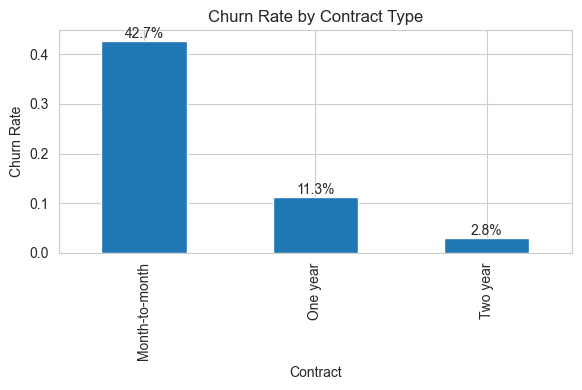

In [17]:
churn_rate = lambda x: (x == 'Yes').mean()

fig, ax = plt.subplots(figsize=(6,4))

result = df.groupby('Contract')['Churn'].apply(churn_rate)
result.plot(kind='bar', ax=ax)

for i, value in enumerate(result):
    ax.text(i, value, f'{value:.1%}', ha='center', va='bottom')

ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Contract Type')
plt.tight_layout()
plt.show()


# Insight: Month-to-month customers churn at 42.%, significantly higher than annual contract customers.

/var/folders/cp/sgrz3_8n1zxg_54907w2zks00000gn/T/ipykernel_3283/3681843799.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby('tenure_bracket')['Churn'].apply(lambda x: (x == 'Yes').mean())


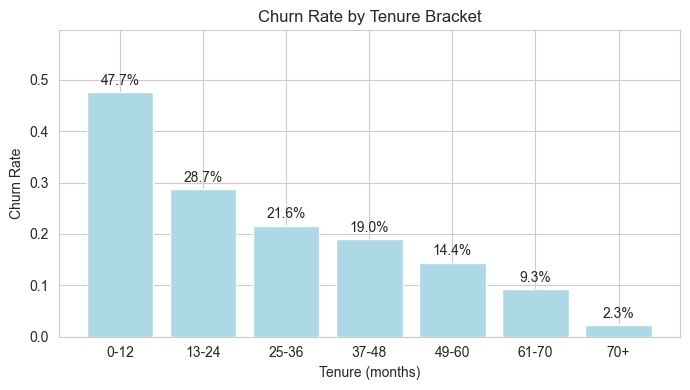

In [23]:
# Define tenure brackets
bins = [0, 12, 24, 36, 48, 60, 70, float('inf')]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-70', '70+']

df['tenure_bracket'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

# Churn rate per bracket
churn_by_tenure = df.groupby('tenure_bracket')['Churn'].apply(lambda x: (x == 'Yes').mean())

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(churn_by_tenure.index, churn_by_tenure.values, color='#ADD8E6')

ax.set_ylabel('Churn Rate')
ax.set_xlabel('Tenure (months)')
ax.set_title('Churn Rate by Tenure Bracket')
ax.set_ylim(0, churn_by_tenure.max() * 1.25)  # extra headroom so labels don't get cut off

# Add data labels as percentages
ax.bar_label(bars, labels=[f'{v:.1%}' for v in churn_by_tenure.values], padding=3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Insight: 47.7% of customers churned during their first 12 months.

/Users/sarahasif/Library/Python/3.9/lib/python/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


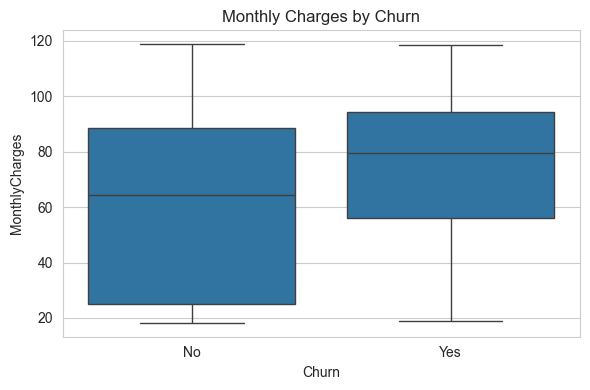

In [24]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax)
ax.set_title('Monthly Charges by Churn')
plt.tight_layout()
plt.show()

# TODO: insight sentence


In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Churn Rate')
ax.set_title('Churn Rate by Payment Method')
plt.tight_layout()
plt.show()

# TODO: insight sentence


## 3. Feature Engineering (1 hr)

In [ ]:
# Copy of the data
data = df.copy()

# Tenure buckets - a business person recognizes these instantly
def tenure_bucket(t):
    if t <= 6:
        return '0-6mo'
    elif t <= 12:
        return '6-12mo'
    elif t <= 24:
        return '1-2yr'
    else:
        return '2yr+'

data['tenure_bucket'] = data['tenure'].apply(tenure_bucket)

# Number of services subscribed
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data['num_services'] = data[service_cols].apply(lambda row: sum(v not in ['No', 'No internet service', 'No phone service'] for v in row), axis=1)

# Customer lifetime value so far (simple proxy)
data['clv_so_far'] = data['tenure'] * data['MonthlyCharges']

data[['tenure', 'tenure_bucket', 'num_services', 'clv_so_far']].head()


In [ ]:
# Encode target and categoricals
data['Churn_flag'] = (data['Churn'] == 'Yes').astype(int)

categorical_cols = data.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ['customerID', 'Churn']]

data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

drop_cols = ['customerID', 'Churn']
X = data_encoded.drop(columns=drop_cols + ['Churn_flag'])
y = data_encoded['Churn_flag']

print(X.shape, y.shape)


## 4. Baseline Model — Logistic Regression (45 min)

Interpretable, and lets you talk about coefficients: *"being on month-to-month increases churn odds by X%."*


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))


In [ ]:
# Look at top coefficients - these become talking points
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': logreg.coef_[0]})
coef_df = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index)
coef_df.head(10)


## 5. Stronger Model — XGBoost / Random Forest (45 min)

In [ ]:
from xgboost import XGBClassifier  # pip install xgboost if not available

xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                     eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


In [ ]:
importances = pd.DataFrame({'feature': X.columns, 'importance': xgb.feature_importances_})
importances = importances.sort_values('importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=importances, x='importance', y='feature', ax=ax)
ax.set_title('Top 10 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# Sanity check: do these match your EDA insights from step 2?


In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


## 6. Translate Predictions into Dollars (1.5 hr)

This is the step that differentiates the project. Use the best model's probabilities.


In [ ]:
results = X_test.copy()
results['actual_churn'] = y_test.values
results['churn_probability'] = y_proba_xgb
results['monthly_charges'] = df.loc[X_test.index, 'MonthlyCharges'].values

# Expected revenue at risk = probability of churn * monthly value
results['expected_revenue_at_risk'] = results['churn_probability'] * results['monthly_charges']

# Risk tiers - thresholds are a judgment call, justify them in your write-up
def risk_tier(p):
    if p >= 0.6:
        return 'High'
    elif p >= 0.3:
        return 'Medium'
    else:
        return 'Low'

results['risk_tier'] = results['churn_probability'].apply(risk_tier)

results[['churn_probability', 'monthly_charges', 'expected_revenue_at_risk', 'risk_tier']].head()


In [ ]:
tier_summary = results.groupby('risk_tier').agg(
    customers=('risk_tier', 'count'),
    total_monthly_revenue_at_risk=('expected_revenue_at_risk', 'sum'),
    avg_churn_prob=('churn_probability', 'mean')
).sort_values('total_monthly_revenue_at_risk', ascending=False)

tier_summary['annualized_revenue_at_risk'] = tier_summary['total_monthly_revenue_at_risk'] * 12
tier_summary


In [ ]:
# Headline number: what if you successfully retain the top 10% highest-risk, highest-value customers?
top_decile = results.sort_values('expected_revenue_at_risk', ascending=False).head(int(len(results) * 0.10))
potential_annual_savings = top_decile['monthly_charges'].sum() * 12

print(f"Potential annual revenue saved by retaining top 10% highest-risk-highest-value customers: ${potential_annual_savings:,.0f}")


## 7. Build One Clean Visual (45 min)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ['Low', 'Medium', 'High']
sns.countplot(data=results, x='risk_tier', order=order, palette='YlOrRd', ax=axes[0])
axes[0].set_title('Customers by Risk Tier')
axes[0].set_ylabel('Number of Customers')

tier_summary.loc[order, 'annualized_revenue_at_risk'].plot(kind='bar', color=['#2ecc71','#f39c12','#e74c3c'], ax=axes[1])
axes[1].set_title('Annualized Revenue at Risk by Tier')
axes[1].set_ylabel('Revenue at Risk ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('churn_risk_dashboard.png', dpi=150)
plt.show()

# This PNG is the image you'll use in your README and LinkedIn post


## 8. Business-Facing README (1 hr)

Write this in a separate `README.md`, not in the notebook. Suggested structure:

1. **Business problem** (2-3 sentences)
2. **Key findings** (3 bullets, plain language, no jargon)
3. **Approach** (1 short paragraph — model used, why)
4. **Recommended action** (what should the retention team actually do)
5. **Revenue impact estimate** (the headline number from Step 6)
6. Link to this notebook for technical detail

Keep code details out of the README body — that's what this notebook is for.


## 9. Publish & Promote (30 min)

- [ ] Push this repo to GitHub with the README as the landing page (not this notebook)
- [ ] Include `churn_risk_dashboard.png` in the README
- [ ] Write a short LinkedIn/portfolio post: business question -> key finding -> dollar impact -> link
- [ ] Double check the repo has a clear name, e.g. `churn-revenue-risk-analysis`
